In [92]:
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# import plotly.express as px

In [93]:
load_dotenv()
database_url = os.getenv('DATABASE_URL')

engine = create_engine(database_url)

df = pd.read_sql('SELECT * FROM storm_events_details_cleaned', engine)
df2 = pd.read_sql('SELECT * FROM storm_events_details', engine)

In [94]:
df2['EVENT_TYPE'].unique()

array(['Thunderstorm Wind', 'Tornado', 'Winter Storm', 'Winter Weather',
       'Hail', 'Flash Flood', 'Flood', 'Marine Thunderstorm Wind',
       'Excessive Heat', 'High Wind', 'Lightning', 'Marine Hail',
       'Frost/Freeze', 'Sneakerwave', 'Heavy Snow', 'Debris Flow',
       'Cold/Wind Chill', 'Funnel Cloud', 'Marine High Wind',
       'Strong Wind', 'Wildfire', 'Dust Storm', 'Drought', 'Heavy Rain',
       'High Surf', 'Blizzard', 'Extreme Cold/Wind Chill', 'Dense Fog',
       'Lake-Effect Snow', 'Ice Storm', 'Avalanche', 'Heat',
       'Rip Current', 'Waterspout', 'Sleet', 'Astronomical Low Tide',
       'Coastal Flood', 'Marine Strong Wind', 'Freezing Fog',
       'Marine Dense Fog', 'Marine Tropical Storm'], dtype=object)

In [95]:
df['EVENT_TYPE'].unique()

array(['Thunderstorm Wind', 'Tornado', 'Flash Flood', 'Flood', 'Hail',
       'Lightning', 'Marine Thunderstorm Wind', 'Marine Hail',
       'Debris Flow', 'Funnel Cloud', 'Marine High Wind', 'Heavy Rain',
       'Waterspout', 'Marine Strong Wind'], dtype=object)

In [96]:
df.columns

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON'],
      dtype='object')

Creating a function where it changes the K's, M's and B's in damages to being actually float values

In [97]:
df2['DAMAGE_PROPERTY']= df2['DAMAGE_PROPERTY'].fillna('0')
df2['DAMAGE_CROPS'] = df2['DAMAGE_CROPS'].fillna('0')

In [98]:
def written_to_full_amount(row):
    if row[-1:] == 'K':
        return float(row[:-1]) * 1000
    elif row[-1:] == 'M':
        return float(row[:-1]) * 1000000
    elif row[-1:] == 'B':
        return float(row[:-1]) * 1000000000
    else:
        return float(row)

In [99]:
df['DAMAGE_CROPS'].iloc[1][-1:]

'K'

In [100]:
# Cleaned Dataset
df['DAMAGE_PROPERTY_FLOAT'] = df['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df['DAMAGE_CROPS_FLOAT'] = df['DAMAGE_CROPS'].apply(written_to_full_amount)
df['Total_Damage_Cost'] = df['DAMAGE_CROPS_FLOAT'] + df['DAMAGE_PROPERTY_FLOAT']
df['END_DATE_TIME_DT'] = df['END_DATE_TIME'].apply(pd.to_datetime)

In [101]:
# Full dataset
df2['DAMAGE_PROPERTY_FLOAT'] = df2['DAMAGE_PROPERTY'].apply(written_to_full_amount)
df2['DAMAGE_CROPS_FLOAT'] = df2['DAMAGE_CROPS'].apply(written_to_full_amount)
df2['Total_Damage_Cost'] = df2['DAMAGE_CROPS_FLOAT'] + df2['DAMAGE_PROPERTY_FLOAT']
df2['END_DATE_TIME_DT'] = df2['END_DATE_TIME'].apply(pd.to_datetime)

In [102]:
# This is the tineframe of our dataset: January to June
df2['BEGIN_YEARMONTH'].sort_values().unique()

array([202501, 202502, 202503, 202504, 202505, 202506])

In [103]:
df.sort_values(by='Total_Damage_Cost',ascending=False)
df_outlier = df[df['Total_Damage_Cost'] <= 1000000000]

In [104]:
df.sort_values(by='Total_Damage_Cost',ascending=False)

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,DAMAGE_PROPERTY_FLOAT,DAMAGE_CROPS_FLOAT,Total_Damage_Cost,END_DATE_TIME_DT
12578,202505,16,1342,202505,16,1349,202193,1262207,MISSOURI,29,...,NE,ST LOUIS,38.6446,-90.3039,38.6894,-90.1974,1.600000e+09,0.0,1.600000e+09,2025-05-16 13:49:00
26119,202505,16,1715,202505,16,1732,202009,1274298,ILLINOIS,17,...,SSE,SARAVILLE,37.6553,-89.0945,37.6599,-88.7970,2.500000e+07,0.0,2.500000e+07,2025-05-16 17:32:00
22236,202506,12,315,202506,12,851,204035,1272324,TEXAS,48,...,ESE,LONGHORN,29.5100,-98.4100,29.5147,-98.4117,2.300000e+07,0.0,2.300000e+07,2025-06-12 08:51:00
26663,202505,16,1816,202505,16,1829,202011,1274626,KENTUCKY,21,...,NW,BOXVILLE,37.6597,-88.0484,37.6548,-87.8679,1.500000e+07,100000.0,1.510000e+07,2025-05-16 18:29:00
8640,202503,14,2227,202503,14,2247,200310,1241249,MISSOURI,29,...,NW,ROMBAUER,36.7229,-90.5729,36.8607,-90.2986,1.500000e+07,0.0,1.500000e+07,2025-03-14 22:47:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28439,202506,16,1610,202506,16,1613,204959,1278368,IOWA,19,...,NNE,MOVILLE,42.5300,-96.0500,42.5300,-96.0500,0.000000e+00,0.0,0.000000e+00,2025-06-16 16:13:00
28438,202506,6,310,202506,6,320,203644,1268432,OKLAHOMA,40,...,SSW,WYNONA,36.5181,-96.3422,36.5181,-96.3422,0.000000e+00,0.0,0.000000e+00,2025-06-06 03:20:00
28437,202506,7,500,202506,7,700,203647,1269743,ARKANSAS,5,...,S,FAYETTEVILLE,36.0700,-94.1700,36.0423,-94.1756,0.000000e+00,0.0,0.000000e+00,2025-06-07 07:00:00
28436,202506,6,651,202506,6,651,203645,1269679,ARKANSAS,5,...,SSE,HACKETT,35.1543,-94.4020,35.1543,-94.4020,0.000000e+00,0.0,0.000000e+00,2025-06-06 06:51:00


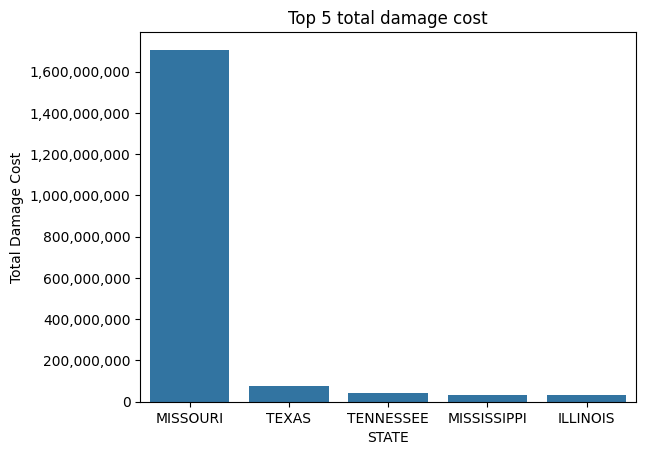

In [105]:
Grouped_State_df = df.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df

ax = sns.barplot(Grouped_State_df.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylabel("Total Damage Cost")
plt.savefig("images/top_5_damage_cost_cleaned.png", bbox_inches = 'tight')
plt.show()

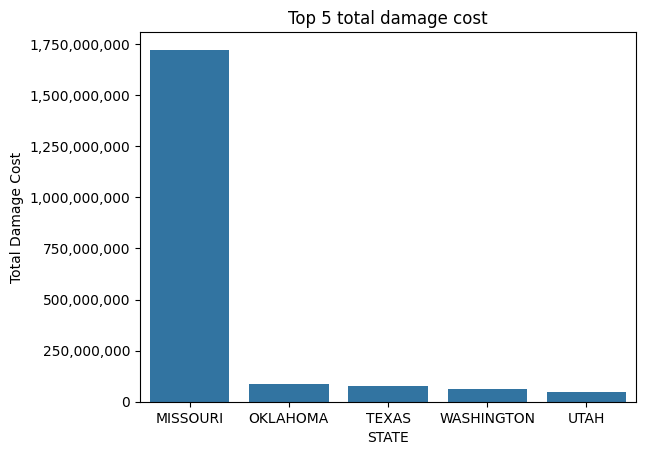

In [106]:
Grouped_State_df2 = df2.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df2

ax = sns.barplot(Grouped_State_df2.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylabel("Total Damage Cost")
plt.savefig("images/top_5_damage_cost_uncleaned.png",bbox_inches = 'tight')
plt.show()

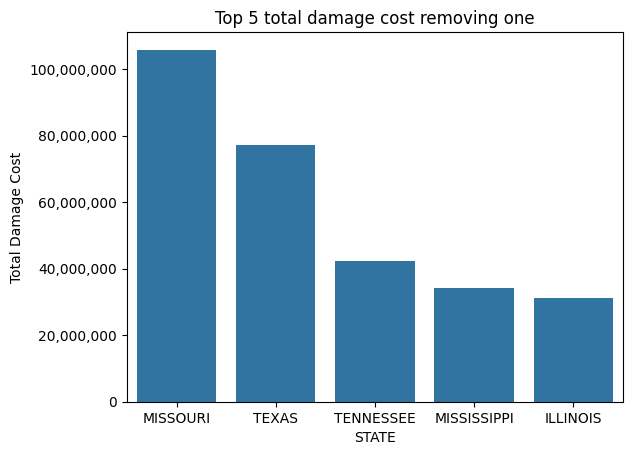

In [107]:
Grouped_State_df_out = df_outlier.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df_out

ax = sns.barplot(Grouped_State_df_out.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost removing one')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylabel("Total Damage Cost")
plt.savefig("images/top_5_damage_cost_outlier_cleaned.png",bbox_inches = 'tight')
plt.show()

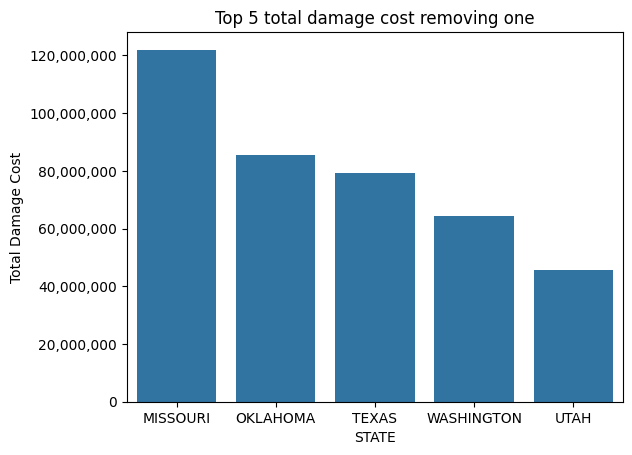

In [108]:
df_outlier2 = df2[df2['Total_Damage_Cost'] <= 1000000000]
Grouped_State_df_out2 = df_outlier2.groupby('STATE', as_index=False)['Total_Damage_Cost'].sum()
Grouped_State_df_out2

ax = sns.barplot(Grouped_State_df_out2.sort_values(by = 'Total_Damage_Cost',ascending = False).head(5),
                 x = 'STATE', y = 'Total_Damage_Cost')
ax.set(title = 'Top 5 total damage cost removing one')
ax.set_ylabel("Total Damage Cost")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.savefig("images/top_5_damage_cost_outlier_uncleaned.png",bbox_inches = 'tight')
plt.show()

In [109]:
US_STATE_ABBREV = {
    'ALABAMA': 'AL',
    'ALASKA': 'AK',
    'ARIZONA': 'AZ',
    'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA',
    'COLORADO': 'CO',
    'CONNECTICUT': 'CT',
    'DELAWARE': 'DE',
    'FLORIDA': 'FL',
    'GEORGIA': 'GA',
    'HAWAII': 'HI',
    'IDAHO': 'ID',
    'ILLINOIS': 'IL',
    'INDIANA': 'IN',
    'IOWA': 'IA',
    'KANSAS': 'KS',
    'KENTUCKY': 'KY',
    'LOUISIANA': 'LA',
    'MAINE': 'ME',
    'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA',
    'MICHIGAN': 'MI',
    'MINNESOTA': 'MN',
    'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO',
    'MONTANA': 'MT',
    'NEBRASKA': 'NE',
    'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH',
    'NEW JERSEY': 'NJ',
    'NEW MEXICO': 'NM',
    'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC',
    'NORTH DAKOTA': 'ND',
    'OHIO': 'OH',
    'OKLAHOMA': 'OK',
    'OREGON': 'OR',
    'PENNSYLVANIA': 'PA',
    'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD',
    'TENNESSEE': 'TN',
    'TEXAS': 'TX',
    'UTAH': 'UT',
    'VERMONT': 'VT',
    'VIRGINIA': 'VA',
    'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI',
    'WYOMING': 'WY'
}

In [110]:
Grouped_State_df['STATE']

0            ALABAMA
1             ALASKA
2     AMERICAN SAMOA
3            ARIZONA
4           ARKANSAS
           ...      
61          VIRGINIA
62        WASHINGTON
63     WEST VIRGINIA
64         WISCONSIN
65           WYOMING
Name: STATE, Length: 66, dtype: object

In [111]:
Grouped_State_df['Total_Damage_Cost'].dtype
Grouped_State_df['STATE'] = Grouped_State_df['STATE'].map(US_STATE_ABBREV)
Grouped_State_df['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [112]:
Grouped_State_df_out['Total_Damage_Cost'].dtype
Grouped_State_df_out['STATE'] = Grouped_State_df_out['STATE'].map(US_STATE_ABBREV)
Grouped_State_df_out['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
61     VA
62     WA
63     WV
64     WI
65     WY
Name: STATE, Length: 66, dtype: object

In [113]:
Grouped_State_df2['Total_Damage_Cost'].dtype
Grouped_State_df2['STATE'] = Grouped_State_df2['STATE'].map(US_STATE_ABBREV)
Grouped_State_df2['STATE']

Grouped_State_df_out2['Total_Damage_Cost'].dtype
Grouped_State_df_out2['STATE'] = Grouped_State_df_out2['STATE'].map(US_STATE_ABBREV)
Grouped_State_df_out2['STATE']

0      AL
1      AK
2     NaN
3      AZ
4      AR
     ... 
62     VA
63     WA
64     WV
65     WI
66     WY
Name: STATE, Length: 67, dtype: object

In [114]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df2,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)
fig.update_layout(title_text = "Total damage cost USA heatmap - Full dataset",
                  title_x = 0.5)
fig.write_image('images/total_damage_uncleaned.png')
fig.show()

In [115]:
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame = Grouped_State_df_out2,
    locations = 'STATE',
    locationmode = 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)
fig.update_layout(title_text = "Total damage cost USA heatmap, removed outlier - Full dataset",
                  title_x = 0.5)
fig.write_image('images/total_damage_outlier_uncleaned.png')

fig.show()

In [116]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame = Grouped_State_df,
    locations = 'STATE',
    locationmode = 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale = 'Viridis'
)
fig.update_layout(title_text = "Total damage cost USA heatmap",
                  title_x = 0.5)
fig.write_image('images/total_damage_cleaned.png')
fig.show()

In [117]:
pio.renderers.default = "browser"
fig = px.choropleth(
    data_frame= Grouped_State_df_out,
    locations = 'STATE',
    locationmode= 'USA-states',
    color = 'Total_Damage_Cost',
    scope = 'usa',
    color_continuous_scale= 'Viridis'
)
fig.update_layout(title_text = "Total damage cost USA heatmap, removed outlier",
                  title_x = 0.5)

fig.write_image('images/total_damage_outlier_cleaned.png')
fig.show()

In [ ]:
engine

In [118]:
# begin_yearmonth = 202501
# for x in range(begin_yearmonth, begin_yearmonth+7):


In [119]:
# df['END_DATE_TIME_DT'] = df['END_DATE_TIME_DT'].dt.to_period("M").dt.to_timestamp()
# df['END_DATE_TIME_DT'].nunique()

In [120]:
# nbformat
# plotly
# kaleido
# import plotly.io as pio

# fig = px.choropleth(
#     data_frame= df,
#     locations = 'STATE',
#     locationmode= 'USA-states',
#     color = 'Total_Damage_Cost',
#     scope = 'usa',
#     animation_frame= 'END_DATE_TIME_DT',
#     color_continuous_scale= 'Viridis'
# )


# fig.show()